## This Section is section for Aksara Jawa Text Divider

This section is for dividing Javanese script text, enabling image processing with the CNN algorithm to recognize and analyze the characters accurately.

We use OpenCV to divide the text, but it only works effectively on images without any background.

#### **First Import depedency needed**

- **cv2**: OpenCV library used for image processing and computer vision tasks, such as reading, editing, and displaying images.
- **numpy (np)**: Library for numerical computation, especially for handling arrays and performing mathematical operations on image data.
- **cv2_imshow**: A function from `google.colab.patches` used to display images in Google Colab, as `cv2.imshow()` does not work in Colab.

In [14]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

#### **Then opened target image with Open CV**
Then, the target image is opened using OpenCV to be processed and analyzed for text segmentation.



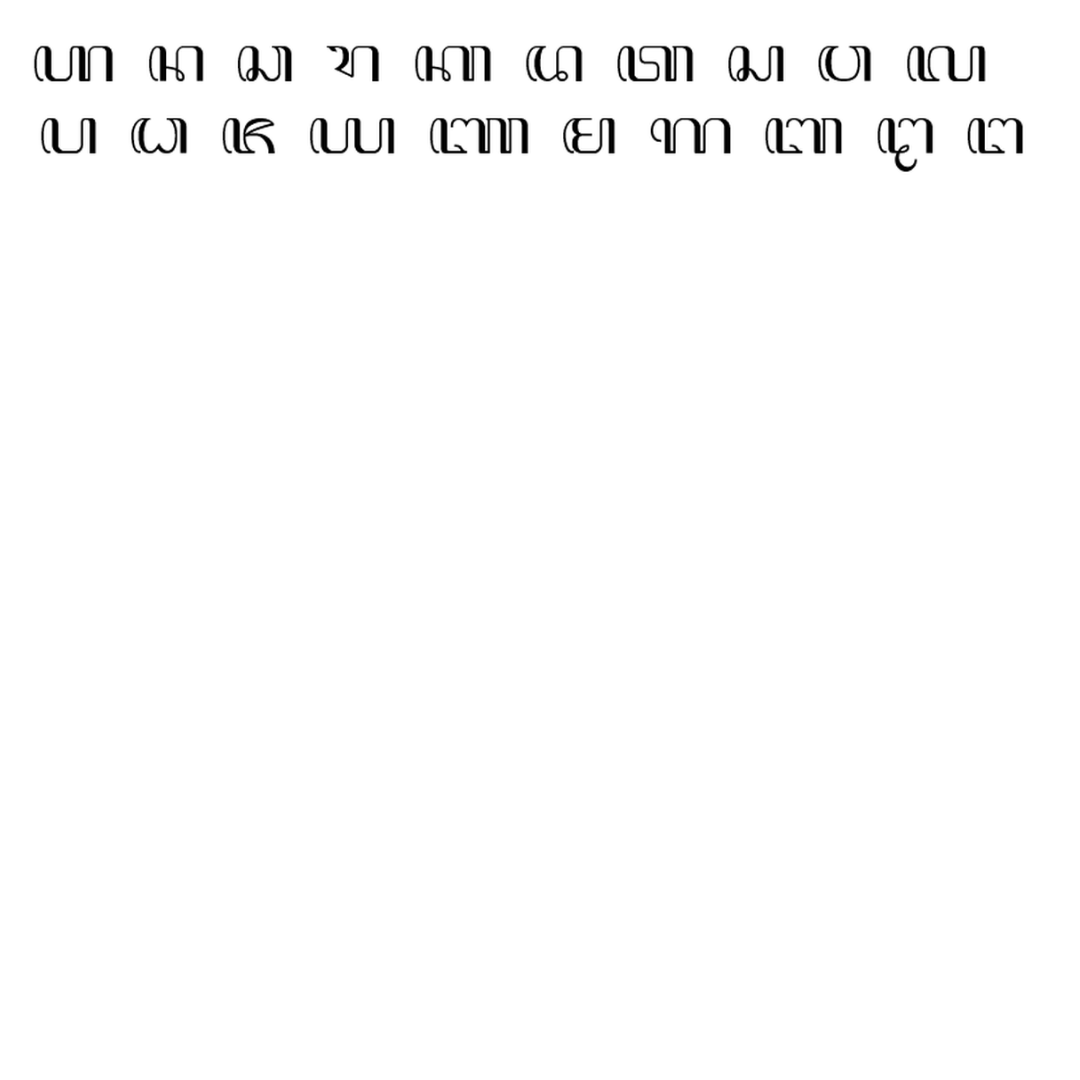

In [20]:
image_path = 'sample1.png'
image = cv2.imread(image_path)
cv2_imshow(image)

The code converts a color image (`image`) to grayscale using OpenCV and displays it using the `cv2_imshow` function.

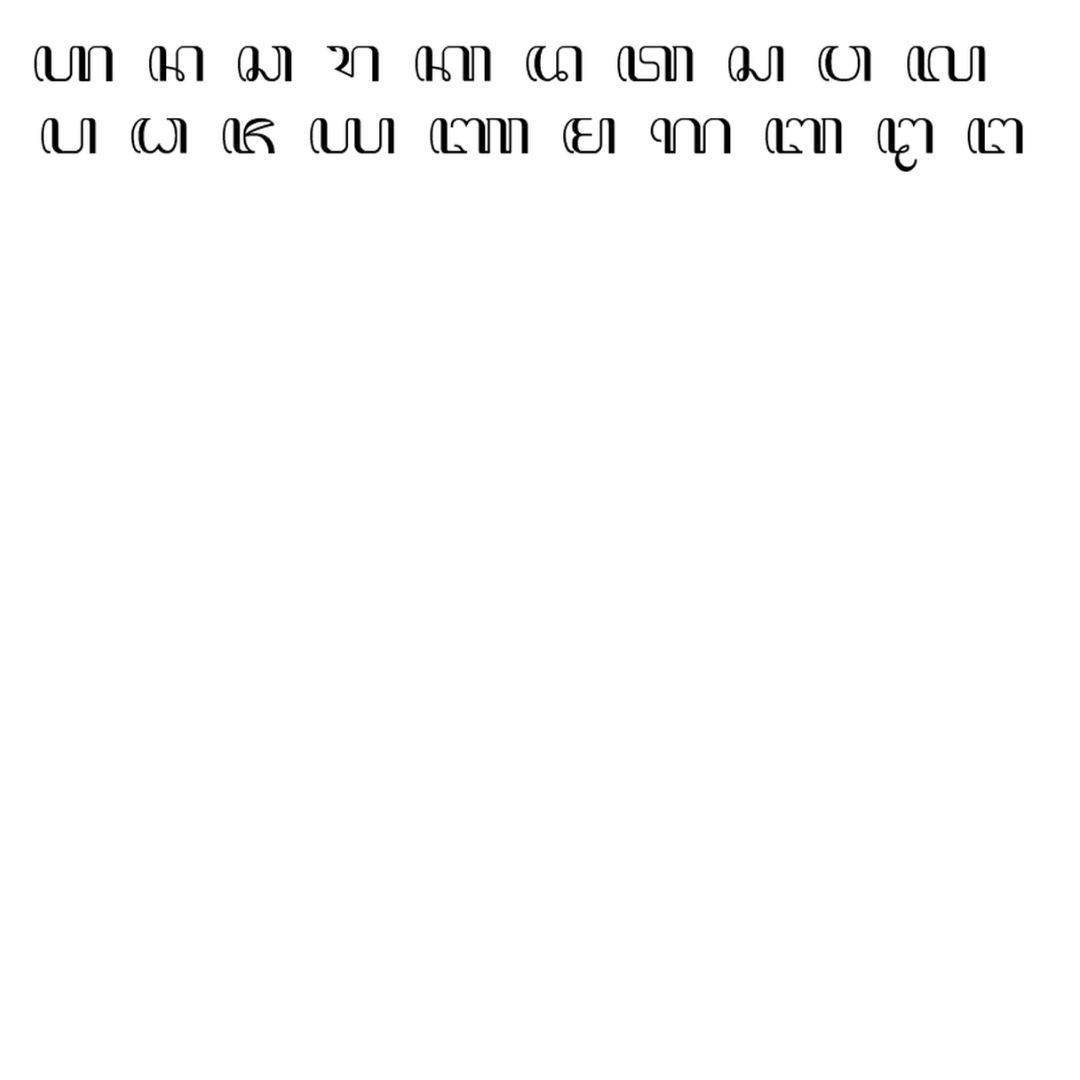

In [21]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
cv2_imshow(gray)

The code applies adaptive thresholding to the grayscale image (`gray`) to create a binary inverted image (`thresh`), refines it using morphological closing with a kernel of size (5,5), and then displays the result using the `cv2_imshow` function.

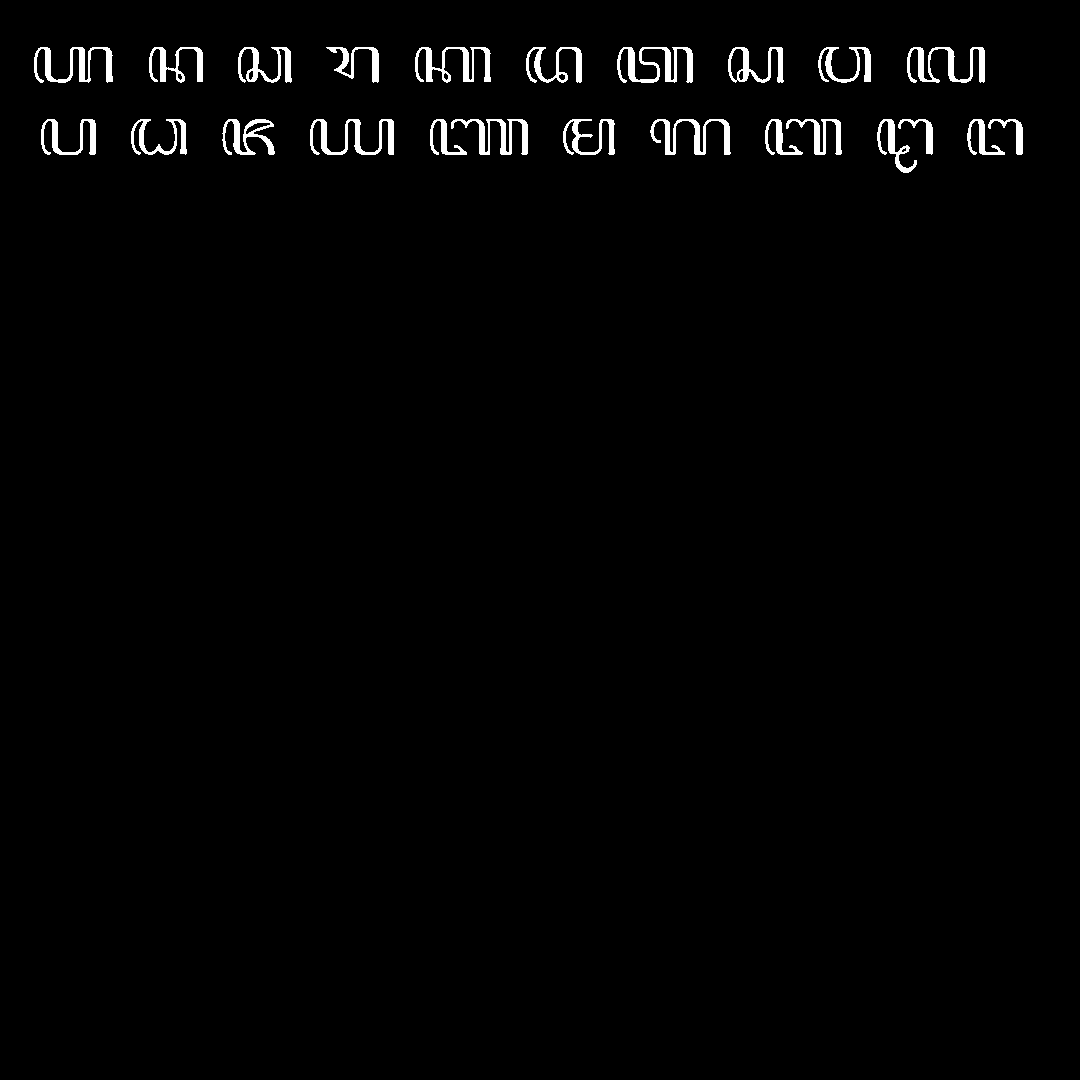

In [22]:
thresh = cv2.adaptiveThreshold(gray,255,cv2.ADAPTIVE_THRESH_GAUSSIAN_C,cv2.THRESH_BINARY_INV,21,10)
thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, (5,5))
cv2_imshow(thresh)

The code applies adaptive Gaussian thresholding on the grayscale image (`gray`) to create a binary inverted image (`thresh`), processes it with morphological closing using a (5,5) kernel to close gaps or small holes, and then displays the processed image with `cv2_imshow`.

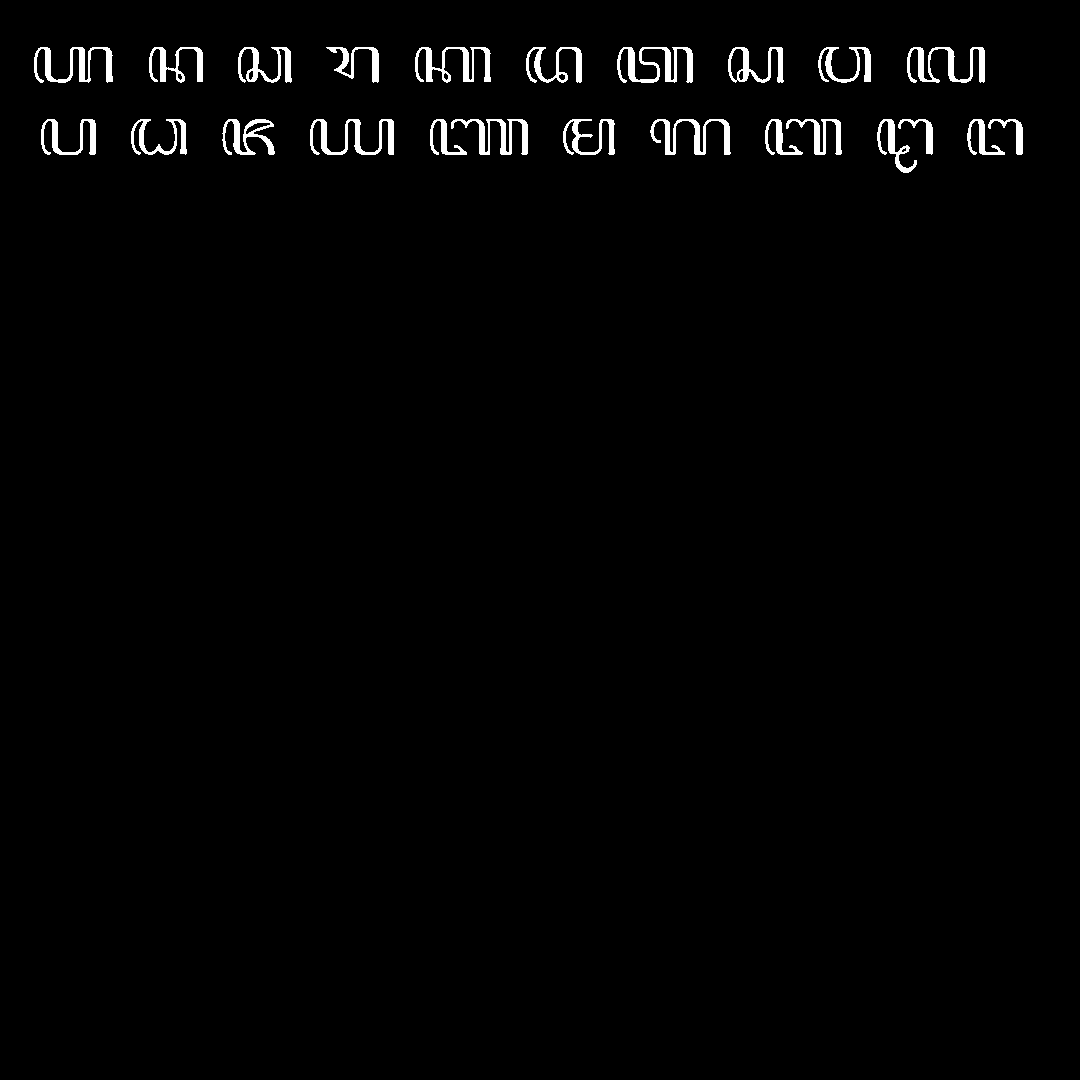

In [23]:
thresh = cv2.adaptiveThreshold(gray,255,cv2.ADAPTIVE_THRESH_GAUSSIAN_C,cv2.THRESH_BINARY_INV,21,10)
thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, (5,5))
cv2_imshow(thresh)

The code performs the following steps:

1. **Morphological Closing:** Refines the binary image (`thresh`) to close small gaps or holes using a morphological closing operation with a (5,5) kernel.  
2. **Connected Components Analysis:** Detects connected components in the binary image, returning the number of components (`nb_components`), labeled regions (`output`), statistics (`stats`), and centroids of the components.  
3. **Component Filtering:** Removes small components smaller than a specified minimum size (`min_size = 50`) by iterating through the component sizes (`sizes`), keeping only those larger or equal to the threshold.  
4. **Output Reconstruction:** Creates a new binary image (`thresh`) where only the filtered components are retained and scales the pixel values for display using `cv2.convertScaleAbs`.  
5. **Display:** Displays the final refined image with `cv2_imshow`.

This Code if modify in next level can see text in any image. Use Machine Learning to study the pattern because the number is different in every image.
  **New Research Method**

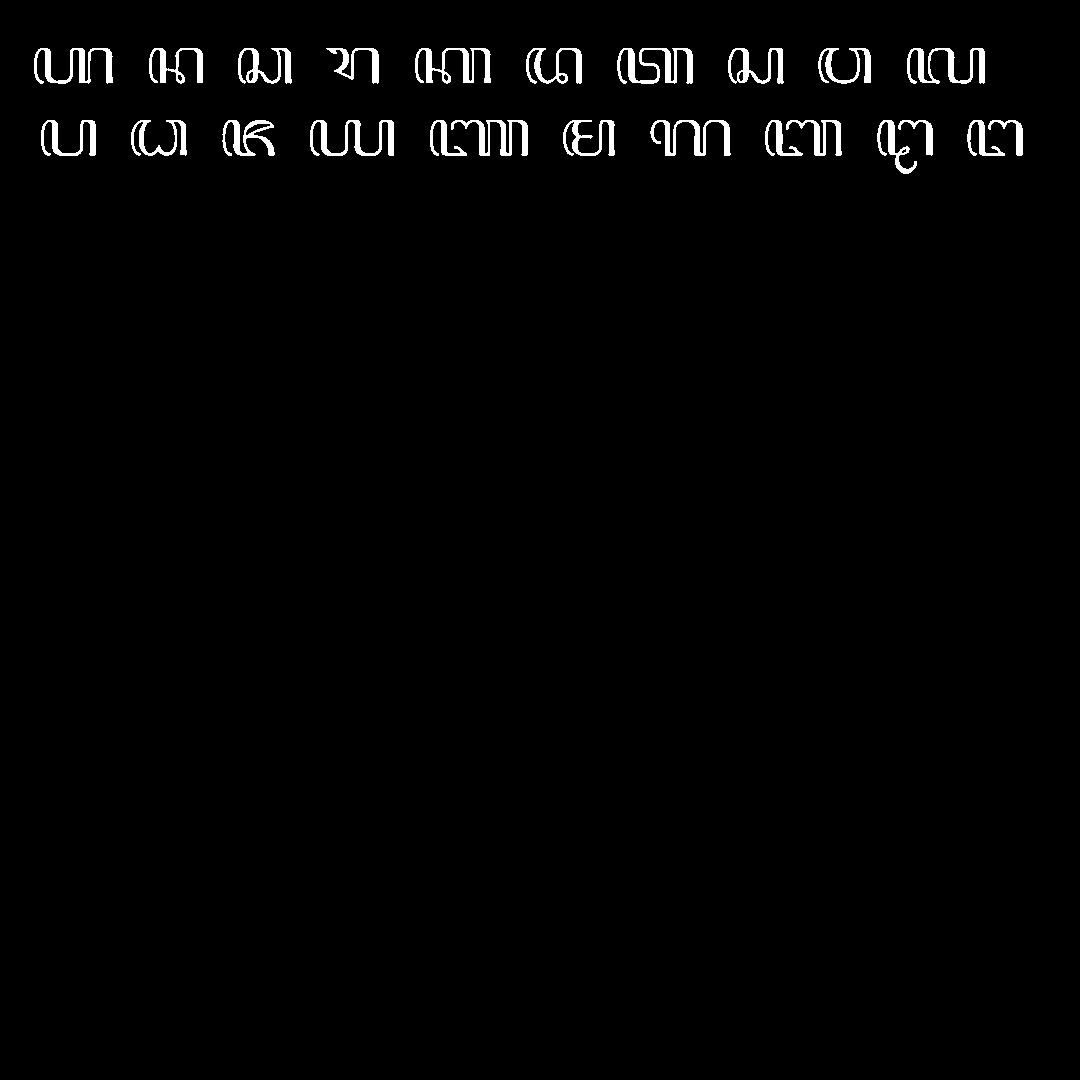

In [24]:
thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, (5,5))
nb_components, output, stats, centroids = cv2.connectedComponentsWithStats(thresh, connectivity=8)
sizes = stats[1:, -1]; nb_components = nb_components - 1
min_size = 50
thresh = np.zeros((output.shape))
for i in range(0, nb_components):
  if sizes[i] >= min_size:
    thresh[output == i + 1] = 255
thresh = cv2.convertScaleAbs(thresh)
cv2_imshow(thresh)

The code performs the following steps:

1. **Contour Detection:** Finds external contours in the binary image (`thresh`) using `cv2.findContours`, where `cv2.RETR_EXTERNAL` retrieves only the external contours, and `cv2.CHAIN_APPROX_SIMPLE` compresses horizontal, vertical, and diagonal segments into endpoints.

2. **Sorting Contours:** Sorts the detected contours (`ctrs`) based on their x-coordinates to process them in left-to-right order.

3. **Bounding Rectangles:** Iterates over the sorted contours, calculates the bounding rectangle (`x, y, w, h`) for each contour using `cv2.boundingRect`, and prints the dimensions.

4. **Region of Interest (ROI):** Extracts a slightly padded region of interest (`roi1`) for each bounding rectangle from the binary image.

5. **Drawing Rectangles:** Draws a magenta rectangle around each contour in the original image (`image`) using `cv2.rectangle`.

6. **Display Image:** Displays the image with drawn rectangles using `cv2_imshow`.

34 48 79 36
41 120 55 36
131 120 56 36
149 48 54 36
222 120 53 36
238 48 54 36
310 120 84 36
326 48 53 36
415 48 76 36
430 120 37 36
451 120 77 36
526 48 56 36
563 120 52 36
617 48 76 36
650 120 81 36
728 48 56 36
765 120 38 36
786 120 56 36
818 48 53 36
877 120 40 54
898 120 35 36
907 48 78 36
967 120 38 36
988 120 35 36


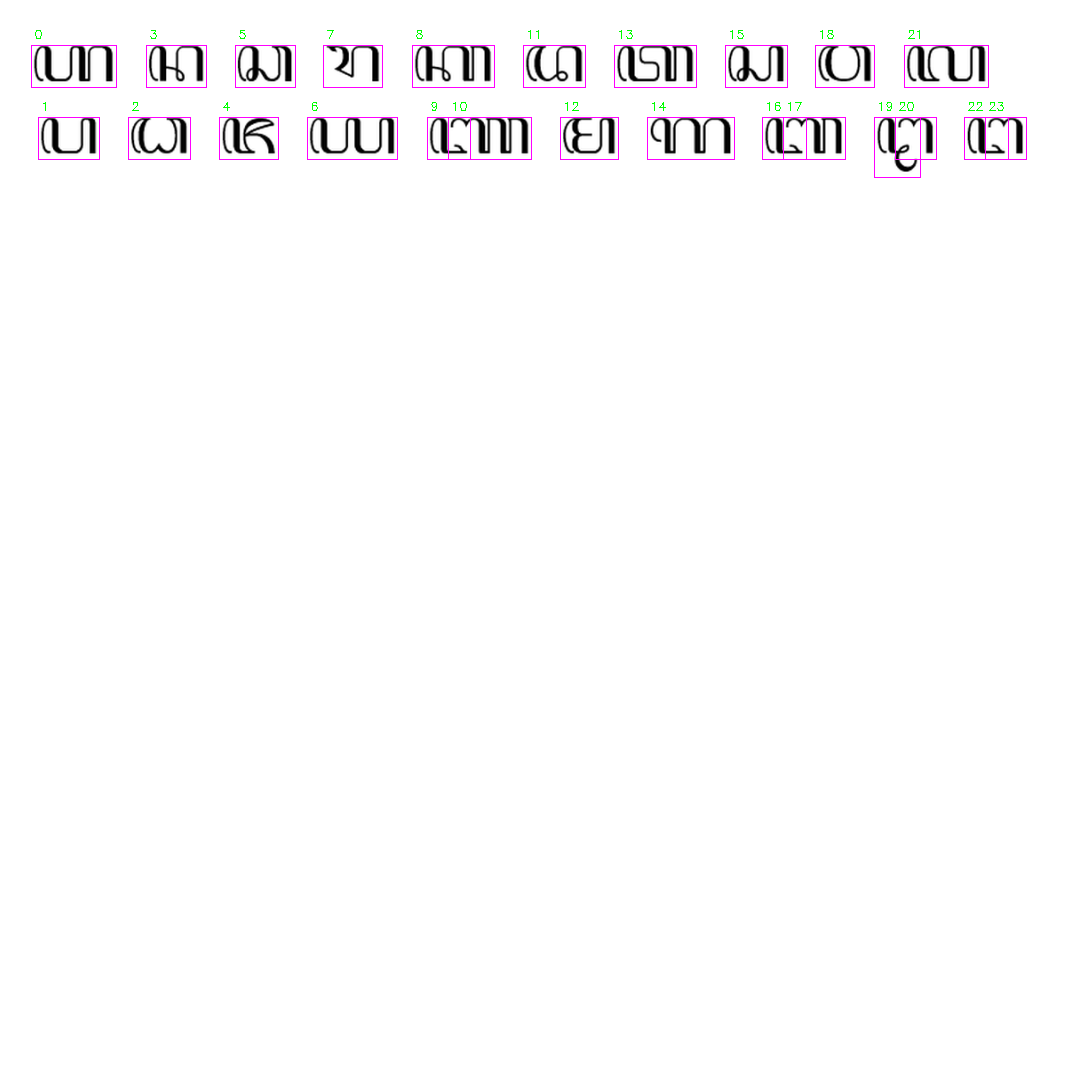

In [25]:
ctrs, hier = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)
#sort contours
sorted_ctrs = sorted(ctrs, key=lambda ctr:cv2.boundingRect(ctr)[0])
for i, ctr in enumerate(sorted_ctrs):
  x, y, w, h = cv2.boundingRect(ctr)
  print(x,y,w,h)
  roi1 = thresh[y-3:y+h+3, x-3:x+w+3]
  cv2.rectangle(image,(x-3,y-3),( x + w + 3, y + h + 3),(255,0,255),1)

  # Add text for position (x, y, w, h)
  position_text = f"{i}"
  cv2.putText(image, position_text, (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 255, 0), 1)
cv2_imshow(image)


That Number is to messy to be calculate we need some sort of graph that control the output of bounding box

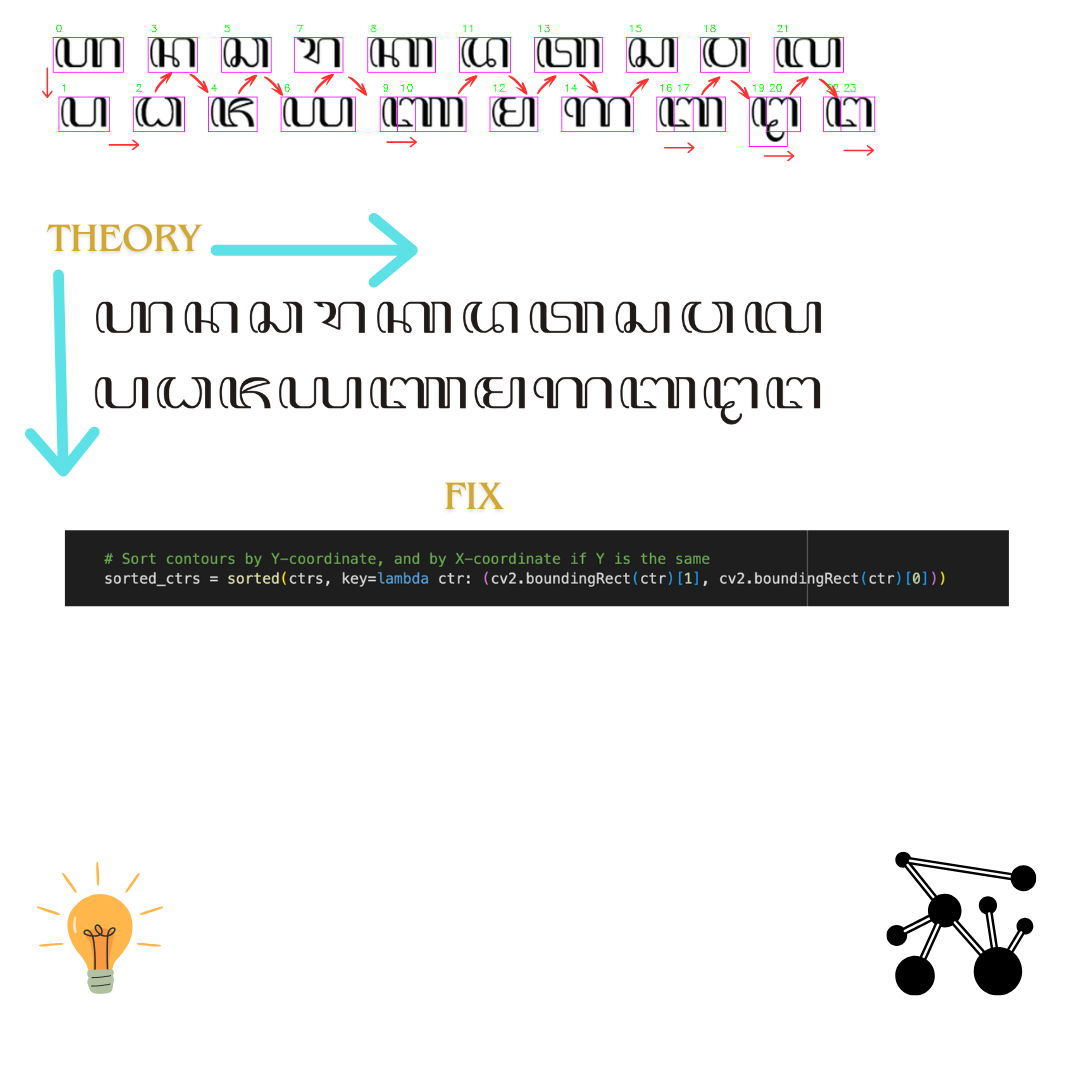

34 48 79 36
149 48 54 36
238 48 54 36
326 48 53 36
415 48 76 36
526 48 56 36
617 48 76 36
728 48 56 36
818 48 53 36
907 48 78 36
41 120 55 36
131 120 56 36
222 120 53 36
310 120 84 36
430 120 37 36
451 120 77 36
563 120 52 36
650 120 81 36
765 120 38 36
786 120 56 36
877 120 40 54
898 120 35 36
967 120 38 36
988 120 35 36


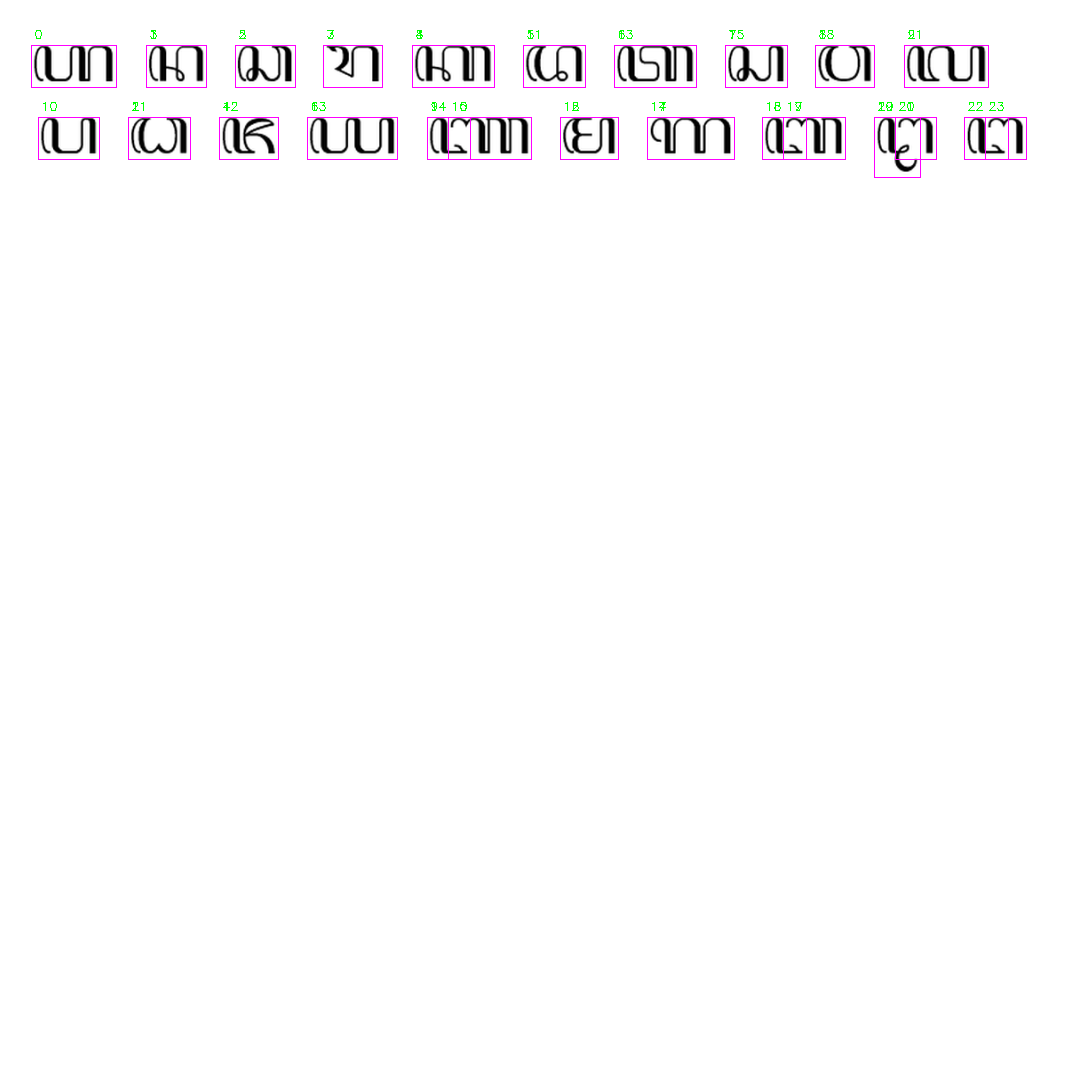

In [26]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# Example threshold image (replace with your actual thresholded image)
# 'image' is the original image.

# Find contours
ctrs, hier = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Sort contours by Y-coordinate, and by X-coordinate if Y is the same
sorted_ctrs = sorted(ctrs, key=lambda ctr: (cv2.boundingRect(ctr)[1], cv2.boundingRect(ctr)[0]))

for i, ctr in enumerate(sorted_ctrs):
    # Get bounding box
    x, y, w, h = cv2.boundingRect(ctr)
    print(x, y, w, h)

    # Extract region of interest (ROI)
    roi1 = thresh[y-3:y+h+3, x-3:x+w+3]

    # Draw bounding box
    cv2.rectangle(image, (x-3, y-3), (x + w + 3, y + h + 3), (255, 0, 255), 1)

    # Add text for position (x, y, w, h)
    position_text = f"{i}"
    cv2.putText(image, position_text, (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 255, 0), 1)

# Display the image with annotations
cv2_imshow(image)


This code snippet manages a directory called `Predict/` by performing the following steps:

1. **Import Necessary Modules:**
   - `os` for handling file system paths and operations.
   - `shutil` for directory and file removal.

2. **Define Directory Path:**  
   The variable `directory` specifies the target directory (`Predict/`).

3. **Check Directory Existence:**  
   It checks if the directory exists using `os.path.exists()`.

4. **Clear Directory Contents:**
   - If the directory exists, it iterates through all files and subdirectories inside.
   - For each item:
     - If it's a file or a symbolic link, it removes it using `os.unlink()`.
     - If it's a directory, it removes it and all its contents recursively using `shutil.rmtree()`.
   - Exceptions during deletion are caught and reported with the specific file path and reason.

5. **Create Directory (If Absent):**  
   If the directory doesn't exist, it creates the directory using `os.makedirs()` and confirms its creation with a print statement.

This ensures the directory is empty and ready for new operations.


In [27]:
import os
import shutil

# Directory path
directory = 'Predict/'

# Check if the directory exists
if os.path.exists(directory):
    # Clear all contents of the directory
    for filename in os.listdir(directory):
        file_path = os.path.join(directory, filename)
        try:
            if os.path.isfile(file_path) or os.path.islink(file_path):
                os.unlink(file_path)  # Remove file or link
            elif os.path.isdir(file_path):
                shutil.rmtree(file_path)  # Remove directory and its contents
        except Exception as e:
            print(f'Failed to delete {file_path}. Reason: {e}')
else:
    # If the directory doesn't exist, create it
    os.makedirs(directory)
    print(f"Created directory: {directory}")


In [28]:
import cv2

# Assuming 'thresh' is your binary image
# Find contours
ctrs, hier = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Sort contours by Y-coordinate, and by X-coordinate if Y is the same
sorted_ctrs = sorted(ctrs, key=lambda ctr: (cv2.boundingRect(ctr)[1], cv2.boundingRect(ctr)[0]))

# Loop through sorted contours
for i, ctr in enumerate(sorted_ctrs):
    # Get bounding box
    x, y, w, h = cv2.boundingRect(ctr)

    # Getting ROI
    roi = thresh[y-3:y+h+3, x-3:x+w+3]

    # Inverting the ROI
    roi = cv2.bitwise_not(roi)

    # Resize ROI to 150x150
    roi = cv2.resize(roi, (150, 150))

    # Saving ROI as an image with bounding box coordinates in the filename
    path = 'Predict/'
    filename = f"cropped-{i}_position_{x}_{y}_{w}_{h}.jpg"  # Including x, y, w, h in the filename
    cv2.imwrite(path + filename, roi)
    print(path + filename)


Predict/cropped-0_position_34_48_79_36.jpg
Predict/cropped-1_position_149_48_54_36.jpg
Predict/cropped-2_position_238_48_54_36.jpg
Predict/cropped-3_position_326_48_53_36.jpg
Predict/cropped-4_position_415_48_76_36.jpg
Predict/cropped-5_position_526_48_56_36.jpg
Predict/cropped-6_position_617_48_76_36.jpg
Predict/cropped-7_position_728_48_56_36.jpg
Predict/cropped-8_position_818_48_53_36.jpg
Predict/cropped-9_position_907_48_78_36.jpg
Predict/cropped-10_position_41_120_55_36.jpg
Predict/cropped-11_position_131_120_56_36.jpg
Predict/cropped-12_position_222_120_53_36.jpg
Predict/cropped-13_position_310_120_84_36.jpg
Predict/cropped-14_position_430_120_37_36.jpg
Predict/cropped-15_position_451_120_77_36.jpg
Predict/cropped-16_position_563_120_52_36.jpg
Predict/cropped-17_position_650_120_81_36.jpg
Predict/cropped-18_position_765_120_38_36.jpg
Predict/cropped-19_position_786_120_56_36.jpg
Predict/cropped-20_position_877_120_40_54.jpg
Predict/cropped-21_position_898_120_35_36.jpg
Predict/cr

In [ ]:
import os

# Directory path
directory = 'Predict/'

# Check if the directory exists
if os.path.exists(directory):
    # List files in the directory
    files = os.listdir(directory)
    print(f"Files in '{directory}':")
    for file in files:
        print(file)
else:
    print(f"The directory '{directory}' does not exist.")


Files in 'Predict/':
cropped-11_position_131_120_56_36.jpg
cropped-3_position_326_48_53_36.jpg
cropped-16_position_563_120_52_36.jpg
cropped-7_position_728_48_56_36.jpg
cropped-12_position_222_120_53_36.jpg
cropped-22_position_967_120_38_36.jpg
cropped-14_position_430_120_37_36.jpg
cropped-9_position_907_48_78_36.jpg
cropped-20_position_877_120_40_54.jpg
cropped-23_position_988_120_35_36.jpg
cropped-19_position_786_120_56_36.jpg
cropped-5_position_526_48_56_36.jpg
cropped-13_position_310_120_84_36.jpg
cropped-15_position_451_120_77_36.jpg
cropped-10_position_41_120_55_36.jpg
cropped-0_position_34_48_79_36.jpg
cropped-1_position_149_48_54_36.jpg
cropped-17_position_650_120_81_36.jpg
cropped-4_position_415_48_76_36.jpg
cropped-21_position_898_120_35_36.jpg
cropped-2_position_238_48_54_36.jpg
cropped-18_position_765_120_38_36.jpg
cropped-6_position_617_48_76_36.jpg
cropped-8_position_818_48_53_36.jpg




> ## Others Method We dont Use because its create more catastropy





ROI 0: Coordinates (33, 45, 81, 37)


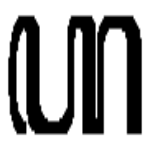

ROI 1: Coordinates (148, 45, 56, 37)


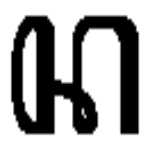

ROI 2: Coordinates (237, 45, 56, 37)


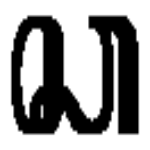

ROI 3: Coordinates (326, 45, 54, 37)


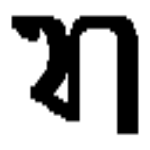

ROI 4: Coordinates (414, 45, 78, 37)


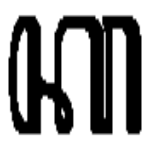

ROI 5: Coordinates (525, 45, 58, 37)


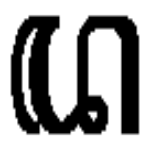

ROI 6: Coordinates (616, 45, 78, 37)


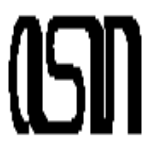

ROI 7: Coordinates (727, 45, 57, 37)


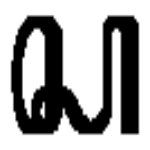

ROI 8: Coordinates (817, 45, 55, 37)


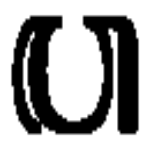

ROI 9: Coordinates (906, 45, 80, 37)


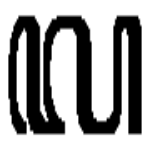

ROI 10: Coordinates (40, 117, 57, 37)


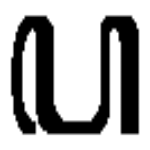

ROI 11: Coordinates (130, 117, 58, 37)


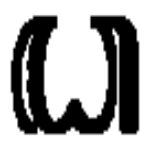

ROI 12: Coordinates (222, 117, 54, 37)


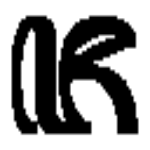

ROI 13: Coordinates (429, 117, 39, 37)


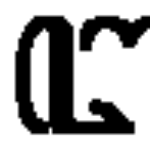

ROI 14: Coordinates (450, 117, 79, 37)


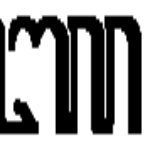

ROI 15: Coordinates (562, 117, 54, 37)


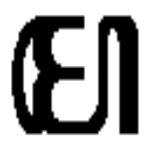

ROI 16: Coordinates (650, 117, 81, 37)


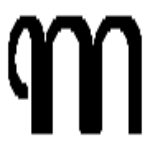

ROI 17: Coordinates (764, 117, 39, 37)


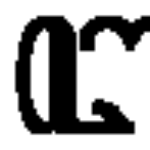

ROI 18: Coordinates (785, 117, 58, 37)


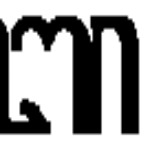

ROI 19: Coordinates (897, 117, 37, 37)


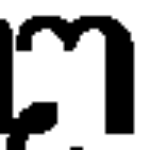

ROI 20: Coordinates (967, 117, 39, 37)


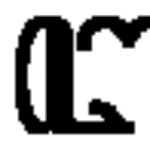

ROI 21: Coordinates (987, 117, 37, 37)


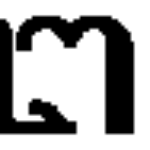

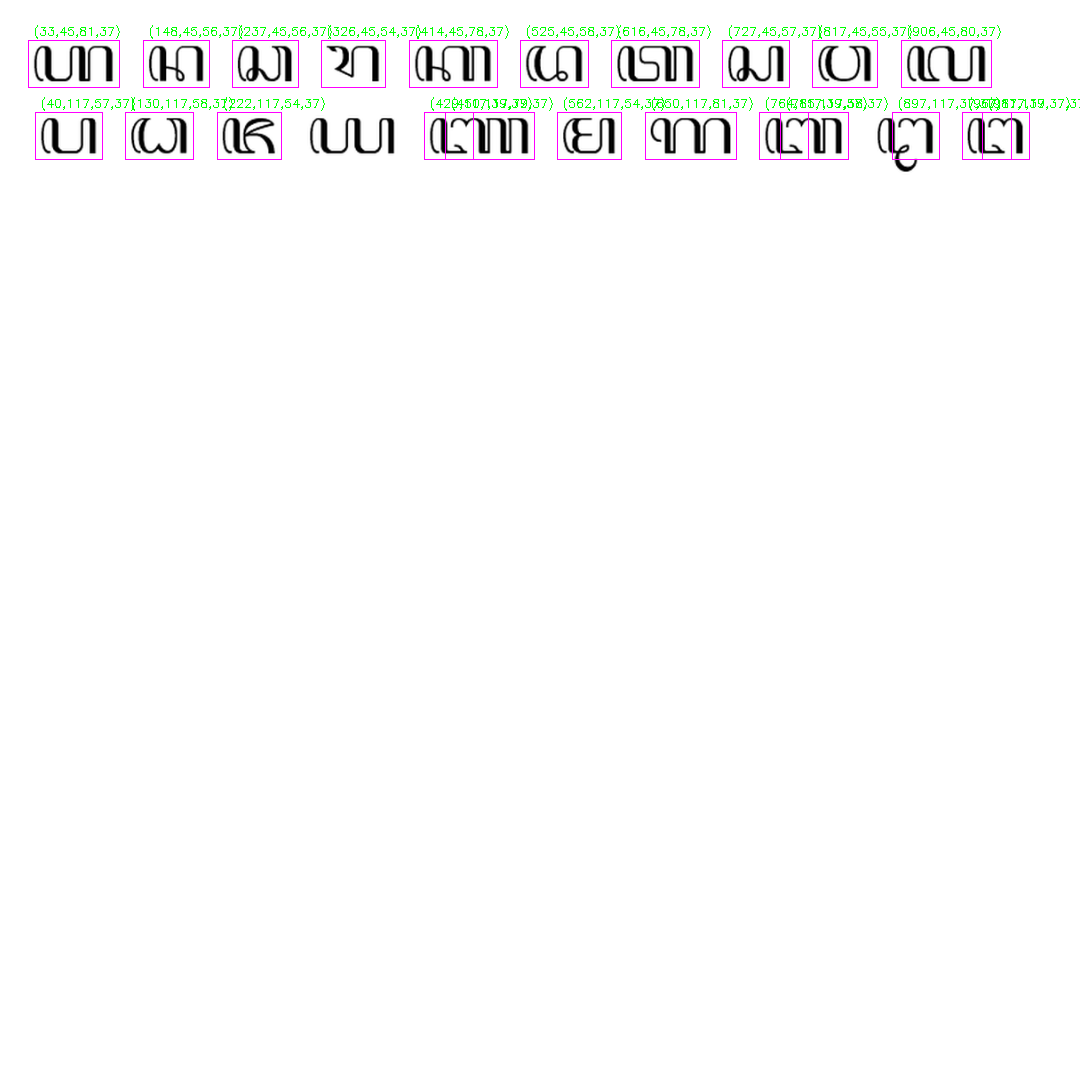

In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# Load your image
image = cv2.imread('Hanacaraka edit.png')
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Thresholding using Otsu's method
thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)[1]

# Dilate to separate nearby contours
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))  # Adjust size as needed
thresh = cv2.dilate(thresh, kernel, iterations=1)

# Find contours
ctrs, hier = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Filter contours based on size
MIN_WIDTH, MAX_WIDTH = 37, 84
MIN_HEIGHT, MAX_HEIGHT = 36, 50

filtered_ctrs = [
    ctr for ctr in ctrs
    if MIN_WIDTH <= cv2.boundingRect(ctr)[2] <= MAX_WIDTH and
       MIN_HEIGHT <= cv2.boundingRect(ctr)[3] <= MAX_HEIGHT
]

# Sort contours by Y first, then X
sorted_ctrs = sorted(filtered_ctrs, key=lambda ctr: (cv2.boundingRect(ctr)[1], cv2.boundingRect(ctr)[0]))

# Draw bounding boxes and display ROIs with padding
PADDING = 5
for i, ctr in enumerate(sorted_ctrs):
    x, y, w, h = cv2.boundingRect(ctr)

    # Add padding
    x_start, y_start = max(x - PADDING, 0), max(y - PADDING, 0)
    x_end, y_end = x + w + PADDING, y + h + PADDING

    # Extract and preprocess ROI
    roi = thresh[y_start:y_end, x_start:x_end]
    roi = cv2.bitwise_not(roi)
    roi = cv2.resize(roi, (150, 150))

    # Visualize each ROI
    print(f"ROI {i}: Coordinates ({x}, {y}, {w}, {h})")
    cv2_imshow(roi)

    # Draw bounding box and label on the original image
    cv2.rectangle(image, (x_start, y_start), (x_end, y_end), (255, 0, 255), 1)
    cv2.putText(image, f"({x},{y},{w},{h})", (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 255, 0), 1)

# Display the final image with bounding boxes
cv2_imshow(image)


In [29]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# Load your image
image_path = '/content/Hanacaraka edit.png'  # Ganti dengan path file gambar
image = cv2.imread(image_path)

# Debug: Check if the image is loaded correctly
if image is None:
    raise FileNotFoundError(f"Error: Unable to load image from {image_path}. Check the file path or file integrity!")

# Convert image to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Thresholding using Otsu's method
thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)[1]

# Dilate to separate nearby contours
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))  # Adjust size as needed
thresh = cv2.dilate(thresh, kernel, iterations=1)

# Find contours
ctrs, hier = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
# Filter contours based on size
MIN_WIDTH, MAX_WIDTH = 37, 84
MIN_HEIGHT, MAX_HEIGHT = 36, 50

filtered_ctrs = [
    ctr for ctr in ctrs
    if MIN_WIDTH <= cv2.boundingRect(ctr)[2] <= MAX_WIDTH and
       MIN_HEIGHT <= cv2.boundingRect(ctr)[3] <= MAX_HEIGHT
]

# Sort contours by Y first, then X
sorted_ctrs = sorted(filtered_ctrs, key=lambda ctr: (cv2.boundingRect(ctr)[1], cv2.boundingRect(ctr)[0]))

# Draw bounding boxes and display ROIs with padding
PADDING = 5
for i, ctr in enumerate(sorted_ctrs):
    x, y, w, h = cv2.boundingRect(ctr)

    # Add padding
    x_start, y_start = max(x - PADDING, 0), max(y - PADDING, 0)
    x_end, y_end = x + w + PADDING, y + h + PADDING

    # Extract and preprocess ROI
    roi = thresh[y_start:y_end, x_start:x_end]
    roi = cv2.bitwise_not(roi)
    roi = cv2.resize(roi, (150, 150))

    # Visualize each ROI
    print(f"ROI {i}: Coordinates ({x}, {y}, {w}, {h})")
    cv2_imshow(roi)

    # Draw bounding box and label on the original image
    cv2.rectangle(image, (x_start, y_start), (x_end, y_end), (255, 0, 255), 1)
    cv2.putText(image, f"({x},{y},{w},{h})", (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 255, 0), 1)

# Display the final image with bounding boxes
cv2_imshow(image)


FileNotFoundError: Error: Unable to load image from /content/Hanacaraka edit.png. Check the file path or file integrity!

In [30]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# Load your image
image_path = '/content/Hanacaraka edit.png'  # Ganti dengan path file gambar
image = cv2.imread(image_path)

# Debug: Check if the image is loaded correctly
if image is None:
    raise FileNotFoundError(f"Error: Unable to load image from {image_path}. Check the file path or file integrity!")

# Convert image to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Thresholding using Otsu's method
thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)[1]

# Dilate to separate nearby contours
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))  # Adjust size as needed
thresh = cv2.dilate(thresh, kernel, iterations=1)

# Find contours
ctrs, hier = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Filter contours based on size
MIN_WIDTH, MAX_WIDTH = 37, 84
MIN_HEIGHT, MAX_HEIGHT = 36, 50

filtered_ctrs = [
    ctr for ctr in ctrs
    if MIN_WIDTH <= cv2.boundingRect(ctr)[2] <= MAX_WIDTH and
       MIN_HEIGHT <= cv2.boundingRect(ctr)[3] <= MAX_HEIGHT
]

# Sort contours by Y first, then X
sorted_ctrs = sorted(filtered_ctrs, key=lambda ctr: (cv2.boundingRect(ctr)[1], cv2.boundingRect(ctr)[0]))

# Draw bounding boxes and display ROIs with padding
PADDING = 5
for i, ctr in enumerate(sorted_ctrs):
    x, y, w, h = cv2.boundingRect(ctr)

    # Apply padding to bounding box and ensure it's within the image bounds
    x_start, y_start = max(x - PADDING, 0), max(y - PADDING, 0)
    x_end, y_end = min(x + w + PADDING, image.shape[1]), min(y + h + PADDING, image.shape[0])

    # Extract and preprocess ROI
    roi = thresh[y_start:y_end, x_start:x_end]
    roi = cv2.bitwise_not(roi)
    roi = cv2.resize(roi, (150, 150))

    # Visualize each ROI
    print(f"ROI {i}: Coordinates ({x}, {y}, {w}, {h})")
    cv2_imshow(roi)

    # Draw bounding box and label on the original image
    cv2.rectangle(image, (x_start, y_start), (x_end, y_end), (255, 0, 255), 1)
    cv2.putText(image, f"({x},{y},{w},{h})", (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 255, 0), 1)

# Display the final image with bounding boxes
cv2_imshow(image)


FileNotFoundError: Error: Unable to load image from /content/Hanacaraka edit.png. Check the file path or file integrity!